## Imports

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

if not hasattr(np, 'int'):
    np.int = int

seed = 7

## Dataset

In [3]:
all_times_df = pd.read_csv('predictors_plus_target_calibrated.csv')
all_times_df = all_times_df.drop(['p6177_i0', 'p90004', 'p4079_i0_a0', 'p94_i0_a0', 'p4080_i0_a0', 'p93_i0_a0', 'p20002_i0_a0', 'p6177_i0', 'p30760_i0', 'p30870_i0'], axis=1)
all_times_df = all_times_df.dropna()
print('Number of Individuals ', len(all_times_df))

Number of Individuals  11583


In [4]:
label_encoder = LabelEncoder()
all_times_df['activity_class'] = label_encoder.fit_transform(all_times_df['activity_class'])

all_times_df['p31'] = pd.factorize(all_times_df['p31'])[0]
all_times_df['p2306_i0'] = pd.factorize(all_times_df['p2306_i0'])[0]
all_times_df['p2443_i0'] = pd.factorize(all_times_df['p2443_i0'])[0]

In [5]:
X = all_times_df[['Mean', 'STD', 'skewR', 'kurtR', 'perc95', 'perc5', 'dPerc', 'Peak power', 'PPFd', 'Entropy', 'PF_sum', 'P_sum', 'p31','Steps']]
y = all_times_df['activity_class']

In [6]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

## Basic Approach

In [7]:
rf_classifier = RandomForestClassifier(random_state=seed)
rf_classifier.fit(X_train_full, y_train_full)
y_pred = rf_classifier.predict(X_test)

In [8]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.8018990073370738


In [9]:
for score in rf_classifier.feature_importances_:
    print(score)

0.24385359341131083
0.09901105656074252
0.0
0.005717327571940774
0.10974091700173831
0.04922225441712535
0.1145913834303116
0.06245683060999351
0.06449519074446712
0.08286919081708097
0.06154022197231611
0.03745080621559927
0.012636543474708994
0.056414683772664745


Confusion Matrix:
[[999 223]
 [236 859]]


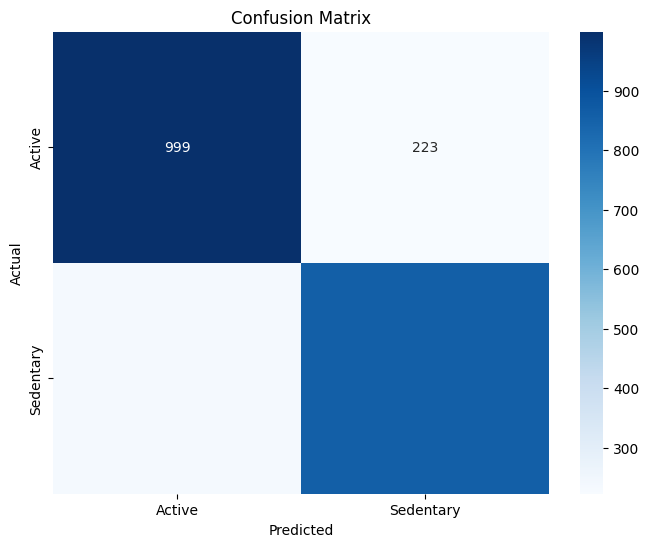

In [10]:
cm = confusion_matrix(y_test, y_pred, labels=rf_classifier.classes_)

print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## GET RECOMMENDER FILE

In [11]:
whole_file = pd.read_csv('whole_file_for_recommender.csv')
whole_file = whole_file[['filename', 'p21022','Mean', 'STD', 'skewR', 'kurtR', 'perc95', 'perc5', 'dPerc', 'Peak power', 'PPFd', 'Entropy', 'PF_sum', 'P_sum', 'p31','Steps']]
whole_file

,filename,p21022,Mean,STD,skewR,kurtR,perc95,perc5,dPerc,Peak power,PPFd,Entropy,PF_sum,P_sum,p31,Steps
0,1273143,60,35.996599,61.781414,1.945474e-33,-5.309941e+15,220.524785,0.056631,220.468154,6.786052e+08,3.927113e+06,12.484088,6.143911e+10,7.315656e+09,Female,3450
1,2071375,58,20.835723,39.551705,-3.984424e-37,-5.309941e+15,163.959431,0.117804,163.841627,1.129343e+09,6.535552e+06,10.393702,2.822986e+10,7.315656e+09,Male,3061
2,2651521,45,38.275334,58.903685,3.256849e-33,-5.309941e+15,220.377875,0.111664,220.266211,9.143790e+08,5.291545e+06,11.634717,4.465024e+10,7.315660e+09,Female,3506
3,4331603,65,6.094688,14.431566,-6.638832e-35,-3.704988e+15,67.816825,0.099472,67.717352,5.178022e+08,2.895850e+06,5.720511,1.240575e+09,5.755036e+09,Male,42
4,2821640,52,48.975911,79.054951,3.991756e-37,-5.309941e+15,291.333570,0.105818,291.227752,1.385132e+09,8.015812e+06,11.938960,6.219940e+10,7.315661e+09,Male,3489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37151,2053485,61,26.083540,42.869528,-5.407031e-34,-5.309941e+15,160.237157,0.228121,160.009036,5.772624e+08,3.340639e+06,12.561447,5.864468e+10,7.315655e+09,Female,3476
37152,4057311,61,13.267840,21.538490,-6.070392e-33,-5.309941e+15,82.650098,0.222024,82.428074,7.539581e+08,4.363184e+06,11.792300,4.519685e+10,7.315622e+09,Male,2866
37153,2213390,69,24.082055,42.124887,-2.610178e-34,-5.309941e+15,160.568186,0.048744,160.519443,8.580044e+08,4.965303e+06,11.056688,3.518452e+10,7.315661e+09,Male,3065
37154,2211084,65,23.401484,43.186637,3.258976e-33,-5.309941e+15,147.914224,0.038020,147.876204,8.663490e+08,5.013594e+06,12.422538,5.775444e+10,7.315658e+09,Male,3468


In [12]:
whole_file = whole_file.dropna()
print('Number of Individuals ', len(whole_file))

Number of Individuals  37145


In [13]:
whole_file['p31'] = pd.factorize(whole_file['p31'])[0]

/var/folders/nv/yh00rxr94090cfx1pg6840p40000gn/T/ipykernel_86607/2007108533.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  whole_file['p31'] = pd.factorize(whole_file['p31'])[0]


In [14]:
y_all = rf_classifier.predict(whole_file.iloc[:,2:])
len(y_all)

37145

In [15]:
whole_file['Predictions'] = y_all
whole_file = whole_file[['filename', 'p21022', 'Predictions']]
whole_file.to_csv('recommender_file_met.csv')

/var/folders/nv/yh00rxr94090cfx1pg6840p40000gn/T/ipykernel_86607/109692653.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  whole_file['Predictions'] = y_all


## Scaled

In [16]:
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

In [17]:
rf_classifier = RandomForestClassifier(random_state=seed)
rf_classifier.fit(X_train_full_scaled, y_train_full)
y_pred = rf_classifier.predict(X_test_scaled)

In [18]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.8053517479499352


## Skewness

In [19]:
from scipy.stats import skew

X_copy = X.copy(deep=True)

numeric_feats = X_copy.select_dtypes(include=['int64', 'float64'])
skewed_feats = numeric_feats.apply(lambda x: skew(x.dropna())).sort_values(ascending=False)

high_skew = skewed_feats[abs(skewed_feats) > 0.75]
print(high_skew)


kurtR         53.784295
perc5         45.870022
PPFd           5.793680
Peak power     3.748328
perc95         2.375254
dPerc          2.350667
STD            2.245639
Mean           0.848573
PF_sum        -1.066204
Entropy       -3.428774
Steps         -3.595157
P_sum         -5.434406
dtype: float64


In [ ]:
plt.subplot(1, 2, 1)
sns.histplot(X['P_sum'].dropna(), kde=True, color='skyblue')
plt.title(f'Before Log Transform')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(X['P_sum'].dropna()), kde=True, color='salmon')
plt.title(f'After Log Transform')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

In [20]:
skewed_features = high_skew.index
X_copy[skewed_features] = np.log1p(X_copy[skewed_features])

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/internals/blocks.py:329: RuntimeWarning: invalid value encountered in log1p
  result = func(self.values, **kwargs)


In [21]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X_copy, y, test_size=0.2, random_state=seed)

In [22]:
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

In [23]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')


X_train_full_imputed = imputer.fit_transform(X_train_full_scaled)
X_test_imputed = imputer.transform(X_test_scaled)

In [24]:
# Now train the model
rf_classifier = RandomForestClassifier(random_state=seed)
rf_classifier.fit(X_train_full_imputed, y_train_full)
y_pred = rf_classifier.predict(X_test_imputed)

In [25]:
print("Model Accuracy:", accuracy_score(y_test, y_pred))

Model Accuracy: 0.8092360811394044


## Bayesian

In [26]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)

In [27]:
scaler = StandardScaler()
X_train_full_scaled = scaler.fit_transform(X_train_full)
X_test_scaled = scaler.transform(X_test)

In [28]:
from skopt.space import Integer, Categorical

param_space = {
    'n_estimators': Integer(100, 2000),
    'max_depth': Integer(2, 50),
    'min_samples_split': Integer(2, 50),
    'min_samples_leaf': Integer(1, 50),
    'max_features': Categorical(['sqrt', 'log2', None, 0.2, 0.5, 0.8])
}


In [29]:
from skopt import BayesSearchCV

opt = BayesSearchCV(
    estimator=RandomForestClassifier(random_state=42, criterion='gini', oob_score=True, bootstrap=True),
    search_spaces=param_space,
    n_iter=50,          
    cv=5,
    scoring='accuracy',           
    n_jobs=-1,            
    random_state=seed,
    verbose=0
)

In [30]:
opt.fit(X_train_full_scaled, y_train_full)

BayesSearchCV(cv=5,
              estimator=RandomForestClassifier(oob_score=True, random_state=42),
              n_jobs=-1, random_state=7, scoring='accuracy',
              search_spaces={'max_depth': Integer(low=2, high=50, prior='uniform', transform='normalize'),
                             'max_features': Categorical(categories=('sqrt', 'log2', None, 0.2, 0.5, 0.8), prior=None),
                             'min_samples_leaf': Integer(low=1, high=50, prior='uniform', transform='normalize'),
                             'min_samples_split': Integer(low=2, high=50, prior='uniform', transform='normalize'),
                             'n_estimators': Integer(low=100, high=2000, prior='uniform', transform='normalize')})

In [31]:
best_model = opt.best_estimator_

for score in best_model.feature_importances_:
    print(score)

0.4807455888232398
0.0550572236099514
0.0
0.0
0.11661153862611087
0.018573009473969372
0.1032985434521285
0.03003301062890047
0.036242235080526236
0.0731976936172231
0.03323406774379845
0.012599816688190367
0.018819779508636492
0.021587492747324914


In [32]:
y_pred_best = best_model.predict(X_test_scaled)
print("Model Accuracy:", accuracy_score(y_test, y_pred_best))

Model Accuracy: 0.805783340526543


In [33]:
cm = confusion_matrix(y_test, y_pred_best, labels=best_model.classes_)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[999 223]
 [227 868]]


## Weighted Approach - Weighted Predictions

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=seed)
X_train, X_val, y_train, y_val = train_test_split(X_train_full, y_train_full, test_size=0.2, random_state=seed)

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_val_scaled = scaler.transform(X_val)

In [ ]:
opt.fit(X_train_scaled, y_train)

In [ ]:
class_indices = {label: idx for idx, label in enumerate(best_model.classes_)}

tree_accuracies = [tree.score(X_val_scaled, y_val) for tree in best_model.estimators_]
tree_weights = np.array(tree_accuracies)
tree_weights /= tree_weights.sum()

tree_preds = np.array([tree.predict(X_test_scaled) for tree in best_model.estimators_])

weighted_votes = np.zeros((X_test_scaled.shape[0], len(best_model.classes_)))

for i, preds in enumerate(tree_preds):
    for j, pred in enumerate(preds):
        class_index = class_indices[pred]
        weighted_votes[j, class_index] += tree_weights[i]

final_preds = np.argmax(weighted_votes, axis=1)


accuracy = accuracy_score(y_test, final_preds)
print(f"Final weighted prediction accuracy: {accuracy:.4f}")

print("\nClassification Report for Tuned Model:\n", classification_report(
    y_test, final_preds, target_names=[str(cls) for cls in label_encoder.classes_]
))

cm = confusion_matrix(y_test, final_preds, labels=best_model.classes_)

print("Confusion Matrix:")
print(cm)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


## XGBoost

In [ ]:
from xgboost import XGBClassifier
xgmodel = XGBClassifier(use_label_encoder=False, eval_metric='logloss')


In [ ]:
xgmodel.fit(X_train_full_scaled, y_train_full)
y_pred = xgmodel.predict(X_test_scaled)

accuracy_score(y_test, y_pred)